In [51]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt; plt.style.use('ggplot')
import seaborn as sns
from scipy.special import expit

# Set Up dat

In [52]:
size = 1000

## 1. Unconfounded treatment assignment

In [53]:
treatment = np.random.choice([0, 1], size=size, p=[0.5, 0.5])

# 2. Surrogacy

In [54]:
outcome_function = lambda x: expit(x) + np.random.normal(0, 0.1, size=x.shape)

# -> surrogacy is met

In [55]:
# In the experimental sample
treatment_effect = 1
surrogate = np.random.normal(0, 1, size=size) + treatment_effect * treatment


outcome = outcome_function(surrogate)

<Axes: >

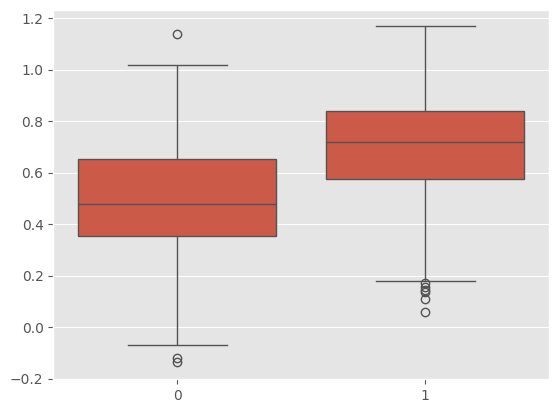

In [56]:
sns.boxplot(x=treatment, y=outcome)

<Axes: >

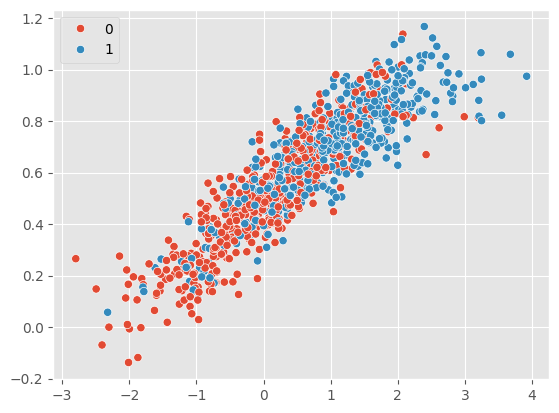

In [57]:
sns.scatterplot(
    x = surrogate,
    y = outcome,
    hue = treatment
)

<Axes: >

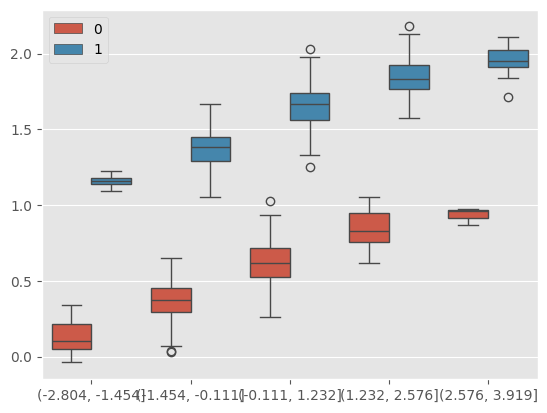

In [64]:
surrogate_bins = pd.cut(x = surrogate, bins=5)
sns.boxplot(x=surrogate_bins, y=outcome, hue=treatment)

# -> surrogacy is not met

In [66]:
# In the experimental sample
outcome = outcome_function(surrogate) + treatment_effect * treatment

<Axes: >

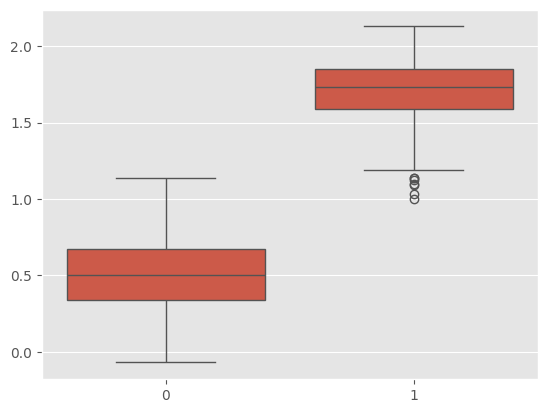

In [67]:
sns.boxplot(x=treatment, y=outcome)

<Axes: >

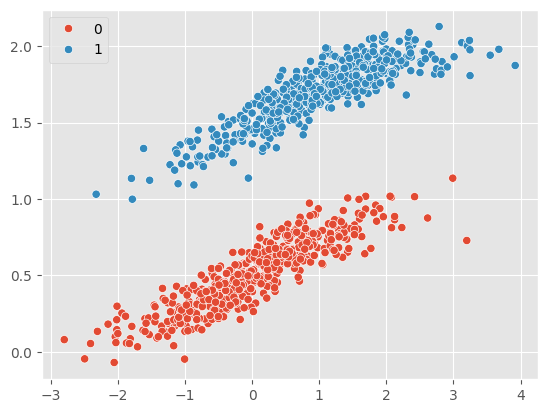

In [68]:
sns.scatterplot(
    x = surrogate,
    y = outcome,
    hue = treatment
)

<Axes: >

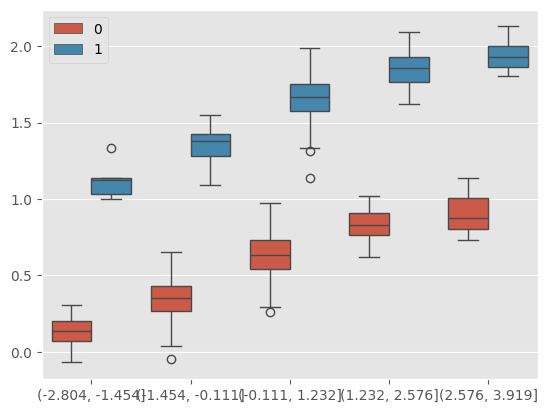

In [69]:
surrogate_bins = pd.cut(x = surrogate, bins=5)
sns.boxplot(x=surrogate_bins, y=outcome, hue=treatment)